# Analyze Hourly Wikipedia Events from S3

In [1]:
# Imports
import boto3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
bucket_name = "dsan6000-tz297"
prefix = "wikipedia-hourly/"

s3 = boto3.client("s3")

response = s3.list_objects_v2(
    Bucket=bucket_name,
    Prefix=prefix
)

parquet_keys = sorted(
    item["Key"]
    for item in response.get("Contents", [])
    if item["Key"].endswith(".parquet")
)

hourly_frames = [
    pd.read_parquet(f"s3://{bucket_name}/{key}")
    for key in parquet_keys
]

events = pd.concat(hourly_frames, ignore_index=True)

print(events.shape)
print(events.columns.tolist())
events.head()

(119708, 29)
['datetime', '$schema', 'meta', 'id', 'type', 'namespace', 'title', 'title_url', 'comment', 'timestamp', 'user', 'bot', 'notify_url', 'minor', 'length', 'revision', 'server_url', 'server_name', 'server_script_path', 'wiki', 'parsedcomment', 'log_id', 'log_type', 'log_action', 'log_params', 'log_action_comment', 'patrolled', 'file_ts', 'file_ts_str']


,datetime,$schema,meta,id,type,namespace,title,title_url,comment,timestamp,...,wiki,parsedcomment,log_id,log_type,log_action,log_params,log_action_comment,patrolled,file_ts,file_ts_str
0,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Jake_O%...,2.063884e+09,edit,0,Jake O'Donnell,https://en.wikipedia.org/wiki/Jake_O%27Donnell,Fix dash,1788235202,...,enwiki,Fix dash,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
1,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Beverid...,2.063884e+09,edit,0,Beveridge Award,https://en.wikipedia.org/wiki/Beveridge_Award,Add source,1788235202,...,enwiki,Add source,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
2,2026-09-01 04:00:01,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1920_Un...,2.063884e+09,edit,0,1920 United States presidential election in Wa...,https://en.wikipedia.org/wiki/1920_United_Stat...,/* Counties that flipped from Democratic to Re...,1788235201,...,enwiki,"<span class=""autocomment""><a href=""/wiki/1920_...",NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
3,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1987_Ae...,2.063884e+09,edit,0,1987 Aegean crisis,https://en.wikipedia.org/wiki/1987_Aegean_crisis,added a bit of context,1788235202,...,enwiki,added a bit of context,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
4,2026-09-01 04:00:03,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Marvin_...,2.063884e+09,edit,0,Marvin Schwäbe,https://en.wikipedia.org/wiki/Marvin_Schw%C3%A4be,NaN,1788235203,...,enwiki,NaN,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000


## Total Events per Hour

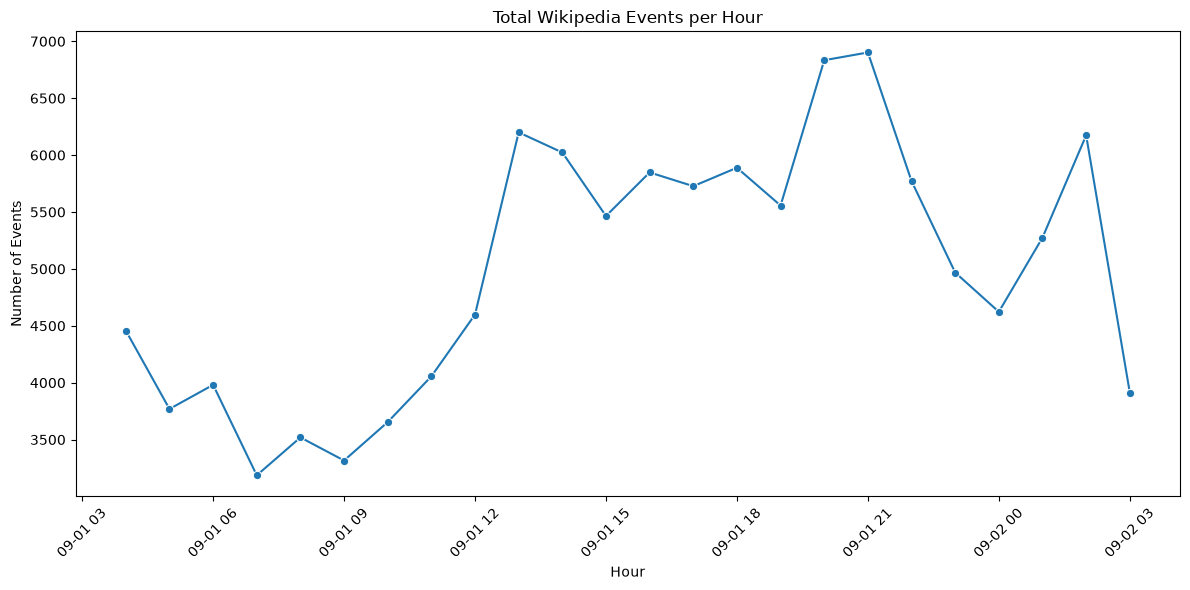

In [3]:
Path("images").mkdir(exist_ok=True)

events["hour"] = pd.to_datetime(
    events["datetime"],
    utc=True
).dt.floor("h")

hourly_counts = (
    events.groupby("hour")
    .size()
    .reset_index(name="event_count")
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=hourly_counts,
    x="hour",
    y="event_count",
    marker="o"
)
plt.title("Total Wikipedia Events per Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Events")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("images/hourly-events.png", dpi=300)
plt.savefig("images/hourly-events.svg")
plt.show()

## Events per Hour by Type

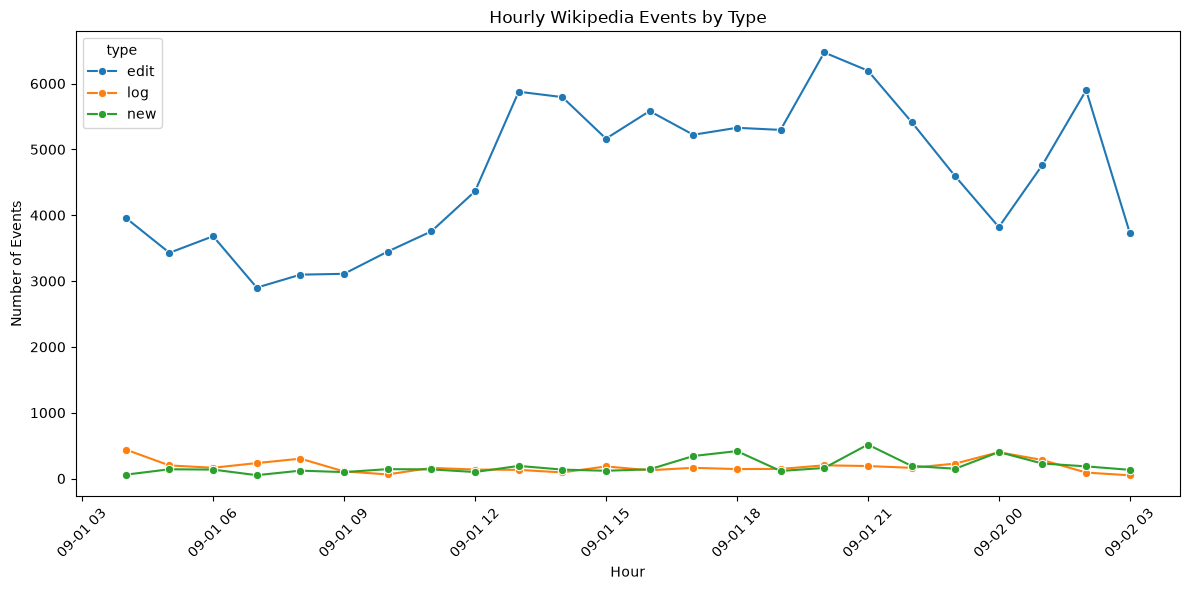

In [4]:
events_by_type = (
    events.groupby(["hour", "type"])
    .size()
    .reset_index(name="event_count")
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=events_by_type,
    x="hour",
    y="event_count",
    hue="type",
    marker="o"
)
plt.title("Hourly Wikipedia Events by Type")
plt.xlabel("Hour")
plt.ylabel("Number of Events")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("images/events-by-type.png", dpi=300)
plt.savefig("images/events-by-type.svg")
plt.show()